# The training of the N2V with PAUS data

Note that here we have the choice of constrained N2V and standard N2V.

In [1]:
import os
os.chdir('../pn2v/src/pn2v')
#os.chdir('../pn2v_ELU/src/pn2v')
from core import prediction
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from unet import UNet
from core import utils
from core import training

import dask.array as da
from dask import compute
import pandas as pd

device=utils.getDevice()

CUDA available? True


In [2]:
os.chdir('../../..')

path1 = './data saved/stamps_515.zarr'
imgs = da.from_zarr(path1)
imgs_part = imgs.compute()

/data/aai/scratch/jchan/miniconda3/envs/denoise/lib/python3.12/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


In [3]:
train_part = imgs_part[:2400]
val_part = imgs_part[2400:]
val_part = np.squeeze(val_part) 

# The training epochs should be larger. (numOfEpochs = 50 is just a test)

In [12]:
path = '../../../model saved/'

trainHist, valHist = training.trainNetwork(net=net, trainData=train_part, valData=val_part,
                                           postfix='name_the_model', directory=path, noiseModel=None,
                                           device=device, numOfEpochs= 50, stepsPerEpoch=10, 
                                           virtualBatchSize=20, batchSize=20, learningRate=6e-4)#7e-4#7e-5

Epoch 0 finished      
avg. loss: 0.04198522102087736+-(2SEM)0.006636469694652182      
Epoch 1 finished      
avg. loss: 0.0296448839828372+-(2SEM)0.0021355514738472655      
Epoch 2 finished      
avg. loss: 0.025977301225066186+-(2SEM)0.001360409040977451      
Epoch 3 finished      
avg. loss: 0.025052884873002768+-(2SEM)0.001223628358029594      
Epoch 4 finished      
avg. loss: 0.023525083623826503+-(2SEM)0.0006602095220420429      
Epoch 5 finished      
avg. loss: 0.02409171499311924+-(2SEM)0.0011413356051257317      
Epoch 6 finished      
avg. loss: 0.024962757341563703+-(2SEM)0.0014268941141286505      
Epoch 7 finished      
avg. loss: 0.0264823280274868+-(2SEM)0.004610637205645336      
Epoch 8 finished      
avg. loss: 0.02363317897543311+-(2SEM)0.0012324616576998234      
Epoch 9 finished      
avg. loss: 0.02382292514666915+-(2SEM)0.0012074269814847897      
Epoch 10 finished      
avg. loss: 0.023317146487534045+-(2SEM)0.0010095085248180645      
Epoch 11 finished    

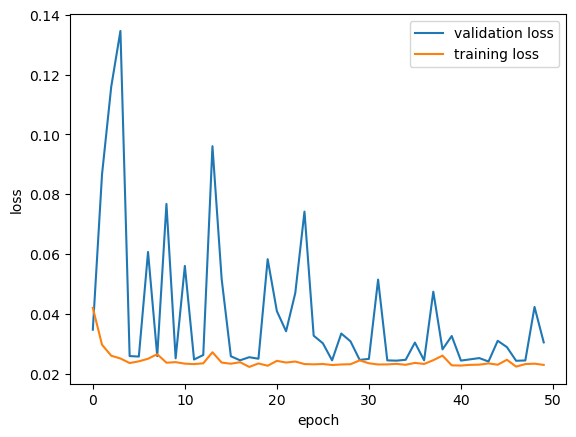

In [13]:
# Let's look at the training and validation loss
plt.xlabel('epoch')
plt.ylabel('loss')
plt.plot(valHist, label='validation loss')
plt.plot(trainHist, label='training loss')
plt.legend()
plt.show()

# Try the validation

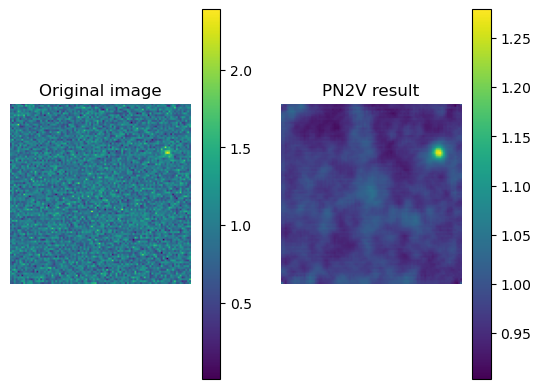

In [40]:
num = 68
n2vResult = prediction.tiledPredict(val_part[num], net ,ps=96, overlap=48,
                                            device=device, noiseModel=None)

fig, axes = plt.subplots(ncols=2)

im1 = axes[0].imshow(val_part[num])
axes[0].set_title('Original image')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0])  # 为第一个子图添加 colorbar

im2 = axes[1].imshow(n2vResult)
axes[1].set_title('PN2V result')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1])  # 为第一个子图添加 colorbar
